# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Adam Kevin
- **Email:** adamkevin514@gmail.com
- **ID Dicoding:** 	CDCC009D6Y0748

## Menentukan Pertanyaan Bisnis

1. Bagaimana segmentasi pelanggan berdasarkan nilai Recency, Frequency, dan Monetary selama periode 2017–2018, serta segmen mana yang paling berkontribusi terhadap total revenue?

2. Kategori produk apa yang memiliki kontribusi tertinggi terhadap total revenue dan jumlah transaksi selama periode 2017–2018?

3. Bagaimana tren jumlah transaksi dan total revenue per bulan selama periode 2017–2018, serta apakah terdapat pola musiman dalam aktivitas pembelian pelanggan?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Data manipulation & analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & time handling
import datetime as dt

# Optional (biar visual lebih bagus)
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Data Wrangling

### Gathering Data



Pada tahap ini dilakukan proses pengumpulan data yang akan digunakan dalam analisis. Dataset yang digunakan adalah **E-Commerce Public Dataset**, yang berisi informasi terkait transaksi pelanggan, produk, pembayaran, serta data pelanggan.

Data ini terdiri dari beberapa file yang saling berelasi, seperti data orders, customers, products, dan order items. Seluruh data akan dimuat ke dalam environment untuk selanjutnya dilakukan proses pembersihan dan analisis lebih lanjut.

In [2]:
from google.colab import files
import zipfile
import io

uploaded = files.upload()


with zipfile.ZipFile(io.BytesIO(uploaded['E-commerce-public-dataset.zip']), 'r') as zip_ref:
    zip_ref.extractall()

Saving E-commerce-public-dataset.zip to E-commerce-public-dataset.zip


In [3]:
#Dataset Utama
customers_df = pd.read_csv('E-Commerce Public Dataset/customers_dataset.csv')
orders_df = pd.read_csv('E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('E-Commerce Public Dataset/order_items_dataset.csv')
payments_df = pd.read_csv('E-Commerce Public Dataset/order_payments_dataset.csv')
products_df = pd.read_csv('E-Commerce Public Dataset/products_dataset.csv')

# Dataset tambahan
category_df = pd.read_csv('E-Commerce Public Dataset/product_category_name_translation.csv')

In [4]:
# Preview dataset
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**

## Insight Data Gathering

Berdasarkan proses data gathering dan preview seluruh dataset, dapat disimpulkan bahwa data yang digunakan terdiri dari beberapa tabel yang saling berelasi, seperti data pelanggan, transaksi, produk, dan pembayaran.

Setiap dataset memiliki peran yang berbeda namun saling melengkapi, sehingga memungkinkan analisis yang komprehensif terkait perilaku pelanggan, performa produk, serta nilai transaksi.

Selain itu, terdapat dataset tambahan yang berfungsi untuk meningkatkan keterbacaan kategori produk, sehingga hasil analisis nantinya dapat lebih mudah dipahami.

### Assessing Data

Data Customers

In [10]:
customers_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [11]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [12]:
customers_df.duplicated().sum()

np.int64(0)

Data Order

In [13]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [14]:
orders_df.isna().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
orders_df.duplicated().sum()

np.int64(0)

Data Order Item

In [16]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [17]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [18]:
order_items_df.duplicated().sum()

np.int64(0)

Data Payment

In [19]:
payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [20]:
payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [21]:
payments_df.duplicated().sum()

np.int64(0)

Data Produk

In [22]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [23]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [24]:
products_df.duplicated().sum()

np.int64(0)

Data Kategori

In [25]:
category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [26]:
category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [27]:
category_df.duplicated().sum()

np.int64(0)

**Insight:**

Berdasarkan proses pemeriksaan kualitas data yang telah dilakukan terhadap seluruh dataset, diperoleh beberapa temuan sebagai berikut:

- Dataset customers, order items, payments, dan product category translation tidak memiliki missing values maupun data duplikat, sehingga dapat langsung digunakan untuk proses analisis.
- Dataset orders memiliki beberapa missing values pada kolom terkait waktu pengiriman, yang kemungkinan disebabkan oleh pesanan yang belum selesai atau tidak berstatus "delivered".
- Dataset products memiliki jumlah missing values yang cukup signifikan, terutama pada informasi kategori dan atribut produk, sehingga memerlukan penanganan lebih lanjut pada tahap data cleaning.
- Beberapa kolom bertipe waktu pada dataset orders dan order items masih dalam format object, sehingga perlu dikonversi ke tipe datetime agar dapat digunakan untuk analisis berbasis waktu.

Secara keseluruhan, data yang digunakan memiliki kualitas yang cukup baik, namun tetap memerlukan proses pembersihan dan transformasi untuk memastikan hasil analisis yang lebih akurat dan optimal.

### Cleaning Data

Convert waktu ke datetime

In [28]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])



Handle Missing Values di data Orders

In [29]:

# Missing values pada kolom terkait pengiriman tidak dihapus
# karena masih memiliki makna (misalnya pesanan belum selesai atau belum dikirim)

# Namun, untuk analisis tertentu, kita bisa memfilter hanya order yang sudah selesai
delivered_orders_df = orders_df[orders_df['order_status'] == 'delivered']

Handle Missing Values di data Products

In [30]:
# Isi kategori yang kosong dengan 'unknown'
products_df['product_category_name'].fillna('unknown', inplace=True)

# Untuk kolom numerik, isi dengan median
products_df['product_name_lenght'].fillna(products_df['product_name_lenght'].median(), inplace=True)
products_df['product_description_lenght'].fillna(products_df['product_description_lenght'].median(), inplace=True)
products_df['product_photos_qty'].fillna(products_df['product_photos_qty'].median(), inplace=True)

products_df['product_weight_g'].fillna(products_df['product_weight_g'].median(), inplace=True)
products_df['product_length_cm'].fillna(products_df['product_length_cm'].median(), inplace=True)
products_df['product_height_cm'].fillna(products_df['product_height_cm'].median(), inplace=True)
products_df['product_width_cm'].fillna(products_df['product_width_cm'].median(), inplace=True)

/tmp/ipykernel_46699/1882002251.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna('unknown', inplace=True)
/tmp/ipykernel_46699/1882002251.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

**Insight:**


Pada tahap data cleaning, dilakukan beberapa proses untuk meningkatkan kualitas data sebelum dianalisis lebih lanjut.

Kolom bertipe waktu pada dataset orders dan order items telah dikonversi ke format datetime agar dapat digunakan dalam analisis berbasis waktu. Selain itu, missing values pada dataset products ditangani dengan metode imputasi, yaitu mengisi nilai kategori dengan "unknown" serta menggunakan nilai median untuk kolom numerik.

Sementara itu, missing values pada dataset orders tidak dihapus karena masih memiliki makna, seperti pesanan yang belum selesai atau belum dikirim.

Secara keseluruhan, proses data cleaning ini membuat data menjadi lebih konsisten dan siap digunakan untuk tahap analisis selanjutnya.

## Exploratory Data Analysis (EDA)

Filter Data sesuai periode

In [47]:
# Filter data sesuai periode
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])

main_df = main_df[
    (main_df['order_purchase_timestamp'].dt.year >= 2017) &
    (main_df['order_purchase_timestamp'].dt.year <= 2018)
]

Explore Tren Order per Bulan

In [49]:
# Buat kolom bulan
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')

# Merge payment_value into main_df
# payment_per_order is created in cell e9CQCZjk8DC2 by summing payment_value per order_id
main_df = pd.merge(main_df, payment_per_order, on='order_id', how='left')

# Hitung jumlah transaksi & revenue per bulan
monthly_trend = main_df.groupby('order_month').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

monthly_trend.head()

,order_month,order_id,payment_value
0,2017-01,800,138488.04
1,2017-02,1780,291908.01
2,2017-03,2682,449863.60
3,2017-04,2404,417788.03
4,2017-05,3700,592918.82


Explore Revenue per Kategori

In [37]:
# =========================
# 1. Aggregate payment per order (hindari double count)
# =========================
payment_per_order = payments_df.groupby('order_id')['payment_value'].sum().reset_index()

# =========================
# 2. Merge datasets
# =========================
# order_items + products
merge_df = pd.merge(order_items_df, products_df, on='product_id', how='left')

# + payment
merge_df = pd.merge(merge_df, payment_per_order, on='order_id', how='left')

# + category translation (optional tapi disarankan)
merge_df = pd.merge(merge_df, category_df, on='product_category_name', how='left')

# =========================
# 3. Handle missing category
# =========================
merge_df['product_category_name_english'] = merge_df['product_category_name_english'].fillna('unknown')

# =========================
# 4. Hitung revenue & jumlah transaksi per kategori
# =========================
category_analysis = merge_df.groupby('product_category_name_english').agg({
    'payment_value': 'sum',
    'order_id': 'nunique'
}).reset_index()

# =========================
# 5. Sort & lihat top kategori
# =========================
category_analysis = category_analysis.sort_values(by='payment_value', ascending=False)

category_analysis.head()

,product_category_name_english,payment_value,order_id
7,bed_bath_table,1712553.67,9417
43,health_beauty,1657373.12,8836
15,computers_accessories,1585330.45,6689
39,furniture_decor,1430176.39,6449
71,watches_gifts,1429216.68,5624


Explore Distribusi Metode Pembayaran

In [38]:
payment_type_dist = payments_df['payment_type'].value_counts().reset_index()
payment_type_dist.columns = ['payment_type', 'count']
payment_type_dist

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


Jumlah order per kota

In [40]:
orders_customers = pd.merge(orders_df, customers_df, on='customer_id')

city_orders = orders_customers['customer_city'].value_counts().reset_index()
city_orders.columns = ['customer_city', 'total_orders']
city_orders.head()

,customer_city,total_orders
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521


**Insight:**

Tren Transaksi dan Revenue

- Berdasarkan hasil eksplorasi, jumlah transaksi dan total revenue menunjukkan tren peningkatan dari awal tahun 2017 hingga pertengahan tahun 2018. Meskipun terdapat fluktuasi pada beberapa bulan, pola umum menunjukkan pertumbuhan aktivitas transaksi pelanggan.
Namun, data pada bulan September 2018 tidak lengkap sehingga tidak digunakan dalam analisis untuk menghindari bias. Oleh karena itu, analisis difokuskan pada periode Januari 2017 hingga Agustus 2018.

Kontribusi Kategori Produk
- Kategori produk seperti bed_bath_table, health_beauty, dan computers_accessories memiliki kontribusi terbesar terhadap total revenue dan jumlah transaksi. Hal ini menunjukkan bahwa kategori tersebut memiliki permintaan yang tinggi dan menjadi pendorong utama penjualan. Selain itu, beberapa kategori seperti watches_gifts memiliki revenue tinggi dengan jumlah transaksi yang relatif lebih rendah, yang mengindikasikan bahwa produk dalam kategori tersebut memiliki nilai transaksi yang lebih besar.

Distribusi Metode Pembayaran
- Metode pembayaran yang paling dominan digunakan adalah credit_card, diikuti oleh boleto. Hal ini menunjukkan bahwa pelanggan cenderung memilih metode pembayaran yang fleksibel dan umum digunakan dalam transaksi online.Metode pembayaran lain seperti voucher dan debit_card memiliki proporsi yang lebih kecil.

Distribusi Order Berdasarkan KOta
- Kota-kota besar seperti Sao Paulo dan Rio de Janeiro memiliki jumlah pesanan yang jauh lebih tinggi dibandingkan kota lainnya.

Temuan ini menunjukkan adanya pola awal yang menarik dan akan dianalisis lebih lanjut pada tahap visualisasi dan explanatory analysis.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana segmentasi pelanggan berdasarkan nilai Recency, Frequency, dan Monetary selama periode 2017–2018, serta segmen mana yang paling berkontribusi terhadap total revenue?

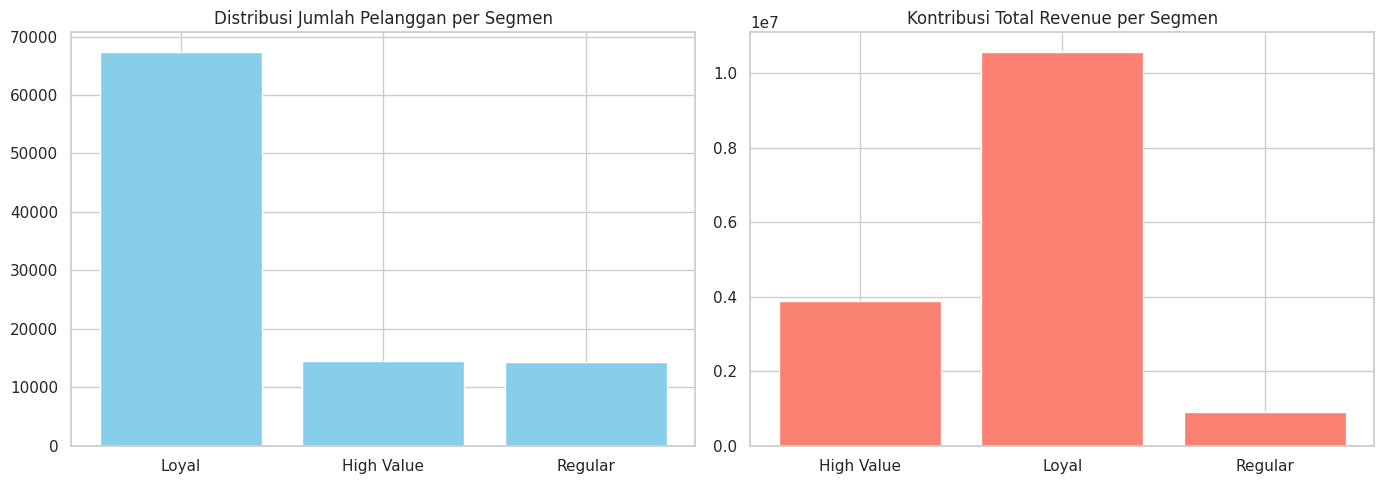

In [50]:
# 1. Filter data di awal (PENTING agar RFM akurat untuk periode 2017-2018)
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_filtered = orders_df[
    (orders_df['order_purchase_timestamp'].dt.year >= 2017) &
    (orders_df['order_purchase_timestamp'].dt.year <= 2018)
].copy()

# Merge dengan pembayaran
rfm_df = pd.merge(orders_filtered, payments_df, on='order_id')
rfm_df = rfm_df[rfm_df['order_status'] == 'delivered']

# 2. Hitung RFM
# Tentukan reference date (biasanya sehari setelah tanggal terakhir di dataset)
reference_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# 3. Segmentasi
rfm['R_score'] = pd.qcut(rfm['Recency'], 3, labels=[3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1,2,3])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 3, labels=[1,2,3])

rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

def segment(score):
    if score >= 8: return 'High Value'
    elif score >= 5: return 'Loyal'
    else: return 'Regular'

rfm['Segment'] = rfm['RFM_score'].apply(segment)

# 4. Analisis Revenue per Segmen
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().reset_index()

# 5. Visualisasi (Gunakan 2 subplot untuk menjawab pertanyaan Anda)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Jumlah Pelanggan
counts = rfm['Segment'].value_counts()
ax1.bar(counts.index, counts.values, color='skyblue')
ax1.set_title('Distribusi Jumlah Pelanggan per Segmen')

# Plot Total Revenue
ax2.bar(revenue_by_segment['Segment'], revenue_by_segment['Monetary'], color='salmon')
ax2.set_title('Kontribusi Total Revenue per Segmen')

plt.tight_layout()
plt.show()

**Insight **

Dominasi Segmen "Loyal": Segmen "Loyal" adalah tulang punggung bisnis . Mereka tidak hanya memiliki jumlah pelanggan terbanyak (mendominasi grafik kiri), tetapi juga memberikan kontribusi pendapatan (revenue) absolut terbesar (grafik kanan). Ini menunjukkan bahwa bisnis sangat bergantung pada volume transaksi yang berulang dari pelanggan setia.

Efisiensi "High Value": Meskipun jumlah pelanggan "High Value" jauh lebih sedikit dibandingkan "Loyal", mereka memberikan kontribusi pendapatan yang sangat signifikan (hampir 40% dari kontribusi "Loyal"). Ini mengindikasikan bahwa setiap pelanggan di segmen ini memiliki nilai transaksi per pelanggan yang jauh lebih tinggi dibandingkan segmen lainnya.

Potensi "Regular": Segmen "Regular" memiliki jumlah pelanggan yang setara dengan "High Value", namun kontribusi pendapatannya sangat kecil. Ini menunjukkan segmen ini mungkin adalah pelanggan baru atau pelanggan yang hanya bertransaksi sesekali (tidak konsisten).

### Pertanyaan 2:

Kategori produk apa yang memiliki kontribusi tertinggi terhadap total revenue dan jumlah transaksi selama periode 2017–2018?

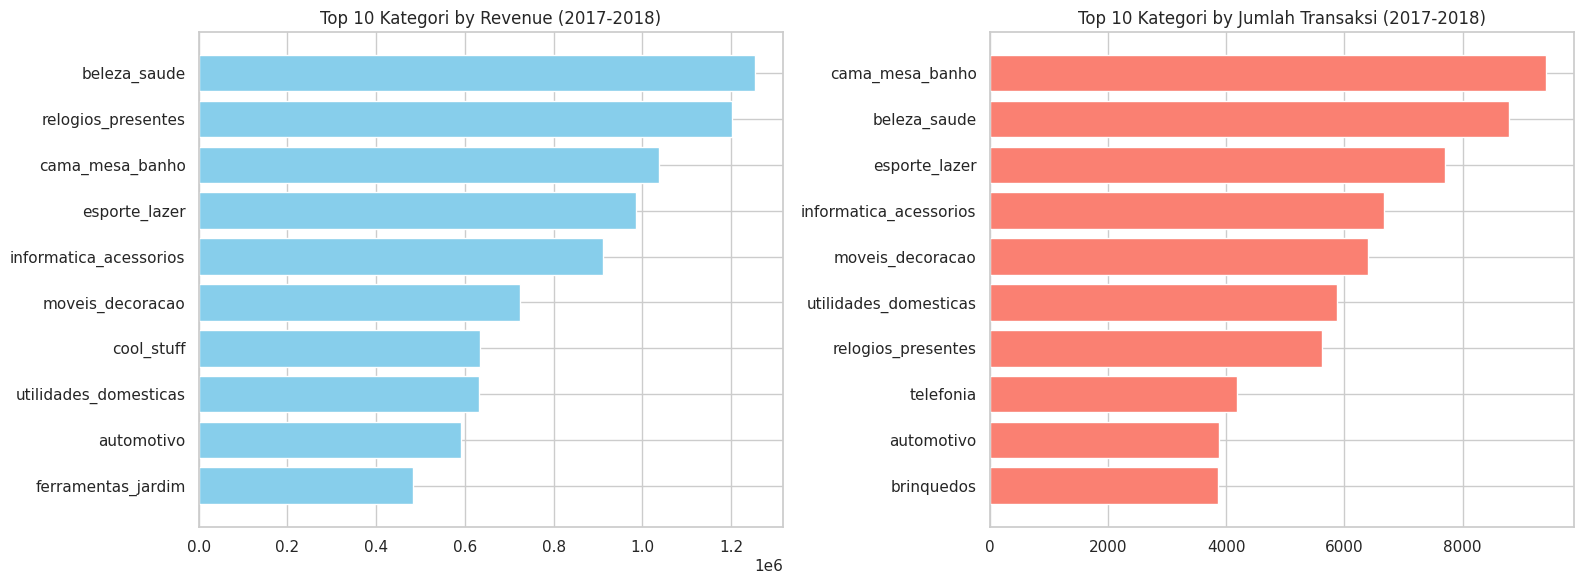

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan semua DataFrame sudah siap
# Kita gabungkan data orders, items, dan products untuk mendapatkan waktu dan kategori
order_full_df = pd.merge(order_items_df, orders_df, on='order_id')
order_full_df = pd.merge(order_full_df, products_df, on='product_id')

# 2. Filter data untuk tahun 2017 sampai 2018
order_full_df = order_full_df[
    (order_full_df['order_purchase_timestamp'].dt.year >= 2017) &
    (order_full_df['order_purchase_timestamp'].dt.year <= 2018)
]

# 3. Analisis per Kategori
# Kita gunakan 'price' untuk Revenue (lebih akurat daripada payments untuk per-item)
product_analysis = order_full_df.groupby('product_category_name').agg({
    'price': 'sum',           # Total Revenue
    'order_id': 'nunique'     # Jumlah Transaksi (unique order)
}).reset_index()

# 4. Ambil Top 10 untuk masing-masing metrik
top_revenue = product_analysis.sort_values(by='price', ascending=False).head(10)
top_transaction = product_analysis.sort_values(by='order_id', ascending=False).head(10)

# 5. Visualisasi dengan 2 Subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Revenue
ax1.barh(top_revenue['product_category_name'], top_revenue['price'], color='skyblue')
ax1.set_title('Top 10 Kategori by Revenue (2017-2018)')
ax1.invert_yaxis()

# Plot Transaksi
ax2.barh(top_transaction['product_category_name'], top_transaction['order_id'], color='salmon')
ax2.set_title('Top 10 Kategori by Jumlah Transaksi (2017-2018)')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

**Insight**

Terdapat perbedaan menarik antara kategori produk yang paling "laris" (jumlah transaksi) dengan kategori yang paling "menguntungkan" (total revenue). Kategori "beleza_saude" (Kecantikan & Kesehatan) adalah bintang utama karena berhasil menempati posisi teratas dalam revenue dan posisi kedua dalam jumlah transaksi. Di sisi lain, "cama_mesa_banho" (Perlengkapan Kamar Tidur, Meja, & Mandi) memimpin dalam jumlah transaksi namun hanya menempati posisi ketiga dalam revenue, yang menunjukkan bahwa produk ini adalah barang kebutuhan pokok dengan volume tinggi namun harga per unit yang lebih terjangkau. Sementara itu, "relogios_presentes" (Jam Tangan & Hadiah) menarik perhatian karena meskipun tidak masuk dalam tiga besar kategori terlaris, kategori ini menduduki posisi kedua dalam kontribusi revenue, yang menandakan bahwa produk ini memiliki nilai jual (ticket size) yang lebih tinggi per transaksinya.

### Pertanyaan 3:
Bagaimana tren jumlah transaksi dan total revenue per bulan selama periode 2017–2018, serta apakah terdapat pola musiman dalam aktivitas pembelian pelanggan?

/tmp/ipykernel_46699/4279945095.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = orders_with_payment.groupby(pd.Grouper(key='order_purchase_timestamp', freq='M')).agg({


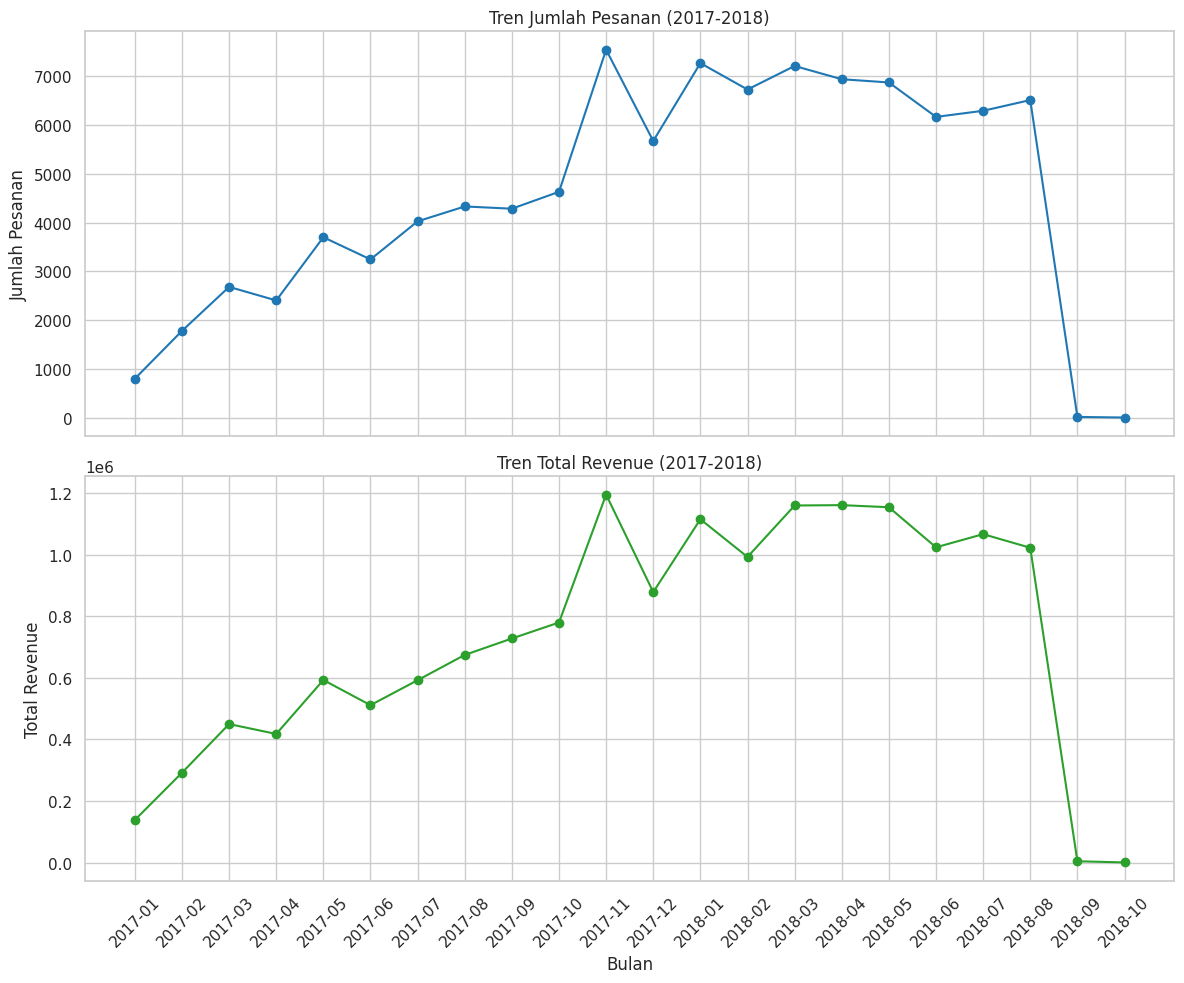

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan kolom timestamp dalam format datetime (sudah dilakukan di tahap cleaning)
# orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

# 2. Filter data untuk tahun 2017 sampai 2018
orders_filtered = orders_df[
    (orders_df['order_purchase_timestamp'].dt.year >= 2017) &
    (orders_df['order_purchase_timestamp'].dt.year <= 2018)
].copy()

# Merge orders_filtered with payment_per_order to include payment_value
# payment_per_order was created in cell e9CQCZjk8DC2 by summing payment_value per order_id
orders_with_payment = pd.merge(orders_filtered, payment_per_order, on='order_id', how='left')

# 3. Agregasi Data Bulanan
# Menggunakan Grouper agar mudah di-plot berdasarkan waktu
monthly_data = orders_with_payment.groupby(pd.Grouper(key='order_purchase_timestamp', freq='M')).agg({
    'order_id': 'count',       # Jumlah pesanan
    'payment_value': 'sum'     # Total revenue
}).reset_index()

# Mengubah format tanggal untuk label sumbu X agar lebih mudah dibaca
monthly_data['month_str'] = monthly_data['order_purchase_timestamp'].dt.strftime('%Y-%m')

# 4. Visualisasi dengan 2 Subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot Jumlah Pesanan
ax1.plot(monthly_data['month_str'], monthly_data['order_id'], marker='o', color='tab:blue')
ax1.set_title('Tren Jumlah Pesanan (2017-2018)')
ax1.set_ylabel('Jumlah Pesanan')
ax1.grid(True)

# Plot Total Revenue
ax2.plot(monthly_data['month_str'], monthly_data['payment_value'], marker='o', color='tab:green')
ax2.set_title('Tren Total Revenue (2017-2018)')
ax2.set_ylabel('Total Revenue')
ax2.set_xlabel('Bulan')
ax2.grid(True)

# Rotasi label sumbu X agar tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**

Berdasarkan hasil visualisasi dan analisis yang telah dilakukan, diperoleh beberapa insight utama sebagai berikut:

- Tren penjualan menunjukkan peningkatan yang signifikan sejak tahun 2017 hingga mencapai puncaknya, kemudian cenderung stabil pada tahun 2018. Penurunan pada periode akhir kemungkinan disebabkan oleh data yang belum lengkap.
- Kategori produk seperti cama_mesa_banho, beleza_saude, dan informatica_acessorios merupakan kontributor utama terhadap total revenue dan jumlah transaksi, yang menunjukkan tingginya permintaan pada kategori tersebut.
- Berdasarkan analisis RFM, pelanggan dapat dikelompokkan menjadi tiga segmen utama yaitu High Value, Loyal, dan Regular. Mayoritas pelanggan berada pada segmen Loyal, yang menunjukkan adanya tingkat retensi pelanggan yang cukup baik.

Secara keseluruhan, bisnis menunjukkan pertumbuhan yang positif dengan didukung oleh kategori produk unggulan serta basis pelanggan yang cukup loyal.

## Analisis Lanjutan (Opsional)

Analisis lanjutan dilakukan menggunakan metode RFM (Recency, Frequency, Monetary) untuk memahami perilaku pelanggan berdasarkan aktivitas transaksi.

In [51]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74,2,1,2,5,Loyal
1,000161a058600d5901f007fab4c27140,410,1,67.41,1,1,1,3,Regular
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42,1,1,3,5,Loyal
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35,1,1,3,5,Loyal
4,000379cdec625522490c315e70c7a9fb,150,1,107.01,3,1,2,6,Loyal


Analisis ini menunjukkan bahwa pelanggan dapat dikelompokkan menjadi beberapa segmen dengan karakteristik berbeda, yang dapat digunakan sebagai dasar strategi pemasaran.

## Conclusion

- Conclution pertanyaan 1

Bisnis saat ini berada dalam fase "Volume-Driven Growth". Pertumbuhan pendapatan sangat ditopang oleh loyalitas pelanggan yang bertransaksi secara rutin. Namun, ada potensi yang belum tergali pada segmen "High Value" (untuk ditingkatkan rata-rata nilainya) dan segmen "Regular" (untuk dikonversi menjadi lebih aktif).

Rekomendasi

Untuk menjaga pelanggan segmen "Loyal", disarankan untuk mengimplementasikan program loyalitas atau keanggotaan eksklusif yang memberikan nilai tambah agar mereka terus merasa dihargai dan termotivasi untuk tetap bertransaksi dalam jangka panjang. Bagi pelanggan segmen "High Value", fokuskan strategi pemasaran pada penawaran produk premium, layanan personal, atau teknik up-selling untuk meningkatkan nilai rata-rata transaksi mereka lebih jauh lagi. Terakhir, untuk segmen "Regular", lakukan kampanye pemasaran ulang yang bersifat personal, seperti pemberian diskon khusus atau penawaran terbatas, guna mendorong frekuensi pembelian mereka agar mereka dapat segera berpindah menjadi pelanggan yang lebih setia.

- Conclution pertanyaan 2

Bisnis memiliki portofolio produk yang seimbang dengan dua penggerak utama: produk kebutuhan harian dengan perputaran cepat (cama_mesa_banho) dan produk bernilai tinggi atau premium (relogios_presentes). Kategori beleza_saude berfungsi sebagai penyeimbang yang kuat karena mampu menarik massa sekaligus menghasilkan pendapatan yang besar. Secara keseluruhan, strategi bisnis tidak bisa disamaratakan untuk semua kategori karena karakteristik perilaku pembelian pelanggan sangat berbeda di setiap segmen produk.

Rekomendasi

Perusahaan harus memprioritaskan ketersediaan stok dan promosi
untuk kategori beleza_saude karena potensi kontribusinya yang paling stabil dan tinggi di kedua metrik.

Untuk kategori cama_mesa_banho, sebaiknya fokus pada strategi bundling atau penawaran paket produk agar nilai rata-rata transaksi meningkat, mengingat volume permintaannya sudah sangat tinggi namun kontribusi pendapatannya belum maksimal.

Gunakan kategori relogios_presentes untuk menargetkan segmen pelanggan VIP atau high-value melalui kampanye pemasaran yang lebih eksklusif, karena kategori ini terbukti mampu mendongkrak revenue meskipun frekuensi pembeliannya tidak seintens produk kebutuhan harian.

Lakukan evaluasi secara berkala pada kategori dengan volume rendah tetapi revenue tinggi, dan pertimbangkan untuk meningkatkan visibilitas produk tersebut melalui iklan yang lebih terarah kepada pelanggan yang sebelumnya pernah membeli produk bernilai tinggi.

 - Conclution Pertanyaan 3

Bisnis perusahaan memiliki fundamental yang kuat dengan pola pertumbuhan yang jelas di tahun 2017 dan stabilitas yang terjaga di tahun 2018. Pola musiman sangat nyata di akhir tahun, yang membuktikan bahwa pelanggan sangat responsif terhadap kampanye promosi besar. Perlu dicatat bahwa penurunan drastis di akhir tahun 2018 kemungkinan besar adalah masalah data availability (data tidak lengkap), bukan penurunan performa bisnis yang sebenarnya.

Rekomendasi
Optimasi Inventaris & Operasional: Karena sudah terbukti adanya lonjakan di akhir tahun (November), perusahaan harus mempersiapkan stok barang dan kapasitas logistik setidaknya 1-2 bulan sebelumnya agar tidak terjadi stockout atau keterlambatan pengiriman saat permintaan memuncak.

Strategi Marketing Berbasis Kalender: Jadikan periode akhir tahun sebagai fokus utama kampanye pemasaran tahunan . Perusahaan bisa mulai membangun antusiasme pelanggan dengan teaser promo sejak Oktober untuk memaksimalkan lonjakan di bulan November.

Fokus pada Customer Lifetime Value (CLV): Mengingat bisnis sudah stabil di tahun 2018, strategi perusahaan harus bergeser dari sekadar mencari pelanggan baru (acquisition) menjadi meningkatkan nilai belanja pelanggan yang sudah ada (retention dan upselling) untuk mendorong pertumbuhan pendapatan di luar musim puncak..

In [52]:
import pandas as pd

# 1. Agregasi payments agar 1 order_id = 1 baris nilai total
payments_agg = payments_df.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': 'first' # Ambil metode pembayaran utama
}).reset_index()

# 2. Lakukan Merge dengan urutan yang benar
main_df = pd.merge(orders_df, customers_df, on='customer_id')
main_df = pd.merge(main_df, order_items_df, on='order_id')
main_df = pd.merge(main_df, products_df, on='product_id')

# 3. Gabungkan hasil aggregasi payments yang sudah aman
main_df = pd.merge(main_df, payments_agg, on='order_id')

# 4. Save
main_df.to_csv('main_data.csv', index=False)

In [53]:
from google.colab import files
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>